---
title: Exploring Hotspots and Coldspots
image: image.png
execute: 
  enabled: true
---

In [1]:
from lokigi.site import SiteProblem
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
problem = SiteProblem()
problem.add_demand("../../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")
problem.add_sites("../../../sample_data/brighton_sites_existing.geojson", candidate_id_col="site")
problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )
problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

problem.add_equity_data(
    "../../../sample_data/Index_of_Multiple_Deprivation_(Dec_2015)_Lookup_in_England.csv",
    equity_col="IMD15",
    common_col="LSOA11NM",
    label="Indices of Multiple Deprivation",
    continuous_measure=True,
    reverse=False
    )

In [3]:
hotspots_df = problem.get_hotspots(what="demand")

C:\lokigi\lokigi\mixins\site_eda.py:140: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.Rook.from_dataframe(df)


In [4]:
hotspots_df

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,LSOA,demand,local_moran_i,p_value,quadrant,cluster_type
0,16356,E01016849,Brighton and Hove 026A,Brighton and Hove 026A,529362,104513,-0.16464,50.82570,2e95f9d0-9795-4cd4-83d1-3a40898b6c89,"POLYGON ((529551.999 104581, 529547.002 104555...",Brighton and Hove 026A,1843,-0.010251,0.448,2,Not Significant
1,16357,E01016850,Brighton and Hove 029A,Brighton and Hove 029A,529926,104360,-0.15669,50.82420,74a1b81a-ffc0-4c96-82ef-c63e7ec28eaf,"POLYGON ((530066.027 104493.355, 529958.177 10...",Brighton and Hove 029A,2433,0.144585,0.194,1,Not Significant
2,16358,E01016851,Brighton and Hove 029B,Brighton and Hove 029B,529674,104404,-0.16025,50.82465,a24f39b6-85f2-4ac6-8af8-f8d205b14b58,"POLYGON ((529453.266 104354.713, 529547.002 10...",Brighton and Hove 029B,2041,0.039325,0.041,1,Hotspot
3,16359,E01016852,Brighton and Hove 026B,Brighton and Hove 026B,529680,104641,-0.16008,50.82678,9d674ffc-b718-4555-b669-0a5e6dc98129,"POLYGON ((529787.909 104744.63, 529784.999 104...",Brighton and Hove 026B,2540,0.504256,0.092,1,Not Significant
4,16360,E01016853,Brighton and Hove 026C,Brighton and Hove 026C,529443,104770,-0.16340,50.82799,7087f545-a012-4c31-afdb-73df930edc2b,"POLYGON ((529461.706 104928.879, 529663.936 10...",Brighton and Hove 026C,2233,-0.161983,0.099,4,Not Significant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,16516,E01017010,Brighton and Hove 017D,Brighton and Hove 017D,536120,105803,-0.06826,50.83575,e99d0ceb-67dc-4d7b-ab1f-ab8b58230e95,"POLYGON ((536567.096 105821.386, 536031.682 10...",Brighton and Hove 017D,1064,0.658483,0.149,3,Not Significant
161,16517,E01017011,Brighton and Hove 017E,Brighton and Hove 017E,537345,105806,-0.05088,50.83549,d60da5d5-da96-4bed-a4e1-f93ffc876538,"POLYGON ((537990.001 104635.399, 537733.25 105...",Brighton and Hove 017E,2536,-0.295819,0.094,4,Not Significant
162,16518,E01017012,Brighton and Hove 017F,Brighton and Hove 017F,535917,104786,-0.07152,50.82666,91575aee-ce23-436e-b85d-d0a94dbcef74,"POLYGON ((536031.682 105223.601, 536625.001 10...",Brighton and Hove 017F,1800,0.004076,0.475,3,Not Significant
163,32444,E01033328,Brighton and Hove 027F,Brighton and Hove 027F,531208,104687,-0.13838,50.82685,f80f534f-bb85-49f8-9b67-730ecab28bad,"POLYGON ((531414.796 104753.739, 531358 104504...",Brighton and Hove 027F,2323,0.296695,0.019,1,Hotspot


<Axes: >

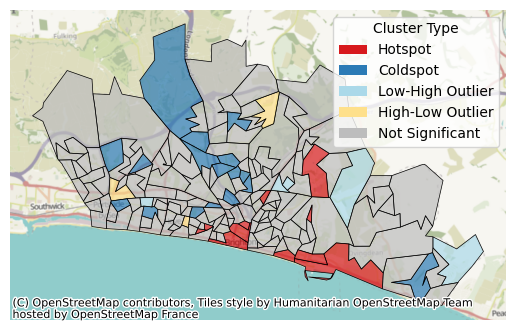

In [5]:
problem.plot_hotspots(hotspots_df=hotspots_df, interactive=False)

<Axes: >

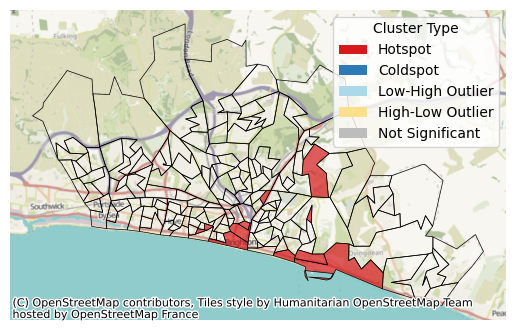

In [6]:
problem.plot_hotspots(hotspots_df=hotspots_df, interactive=False, show_coldspots=False,
                      show_high_low_outliers=False,show_low_high_outliers=False,
                      show_non_significance=False)

In [7]:
problem.plot_hotspots(hotspots_df=hotspots_df, interactive=True)

In [8]:
problem.plot_hotspots(hotspots_df=hotspots_df, interactive=True, show_coldspots=False,
                      show_high_low_outliers=False,show_low_high_outliers=False,
                      show_non_significance=False)

## Equity

We can also use these plots for equity exploration as we have passed in equity data. 

C:\lokigi\lokigi\mixins\site_eda.py:354: UserWarning: Using cached spatial weights.
  w = self._get_weights(


<Axes: >

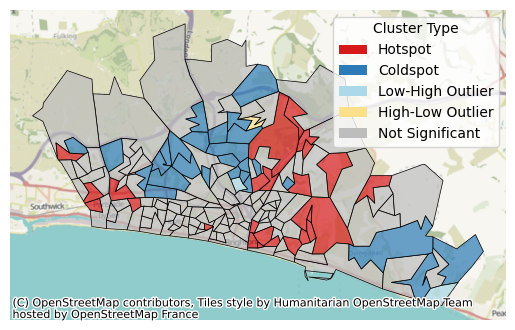

In [9]:
hotspots_equity_df = problem.get_hotspots(what="equity")

problem.plot_hotspots(hotspots_df=hotspots_equity_df, interactive=False)

We can combine both plots into a single plot with some additional matplotlib code. 

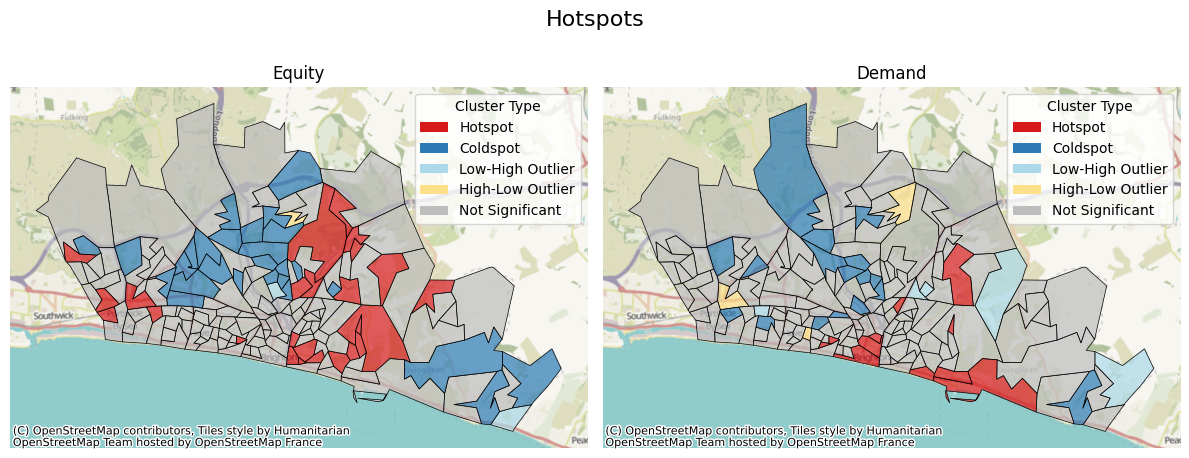

In [10]:
# First we create blank subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Now we pass the relevant axis into our plot_hotspots function
problem.plot_hotspots(hotspots_df=hotspots_equity_df, interactive=False, ax=axes[0])
problem.plot_hotspots(hotspots_df=hotspots_df, interactive=False, ax=axes[1])

# Set the title for each
axes[0].set_title("Equity")
axes[1].set_title("Demand")

# Set an overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

Let's compare this with the raw underlying data. 

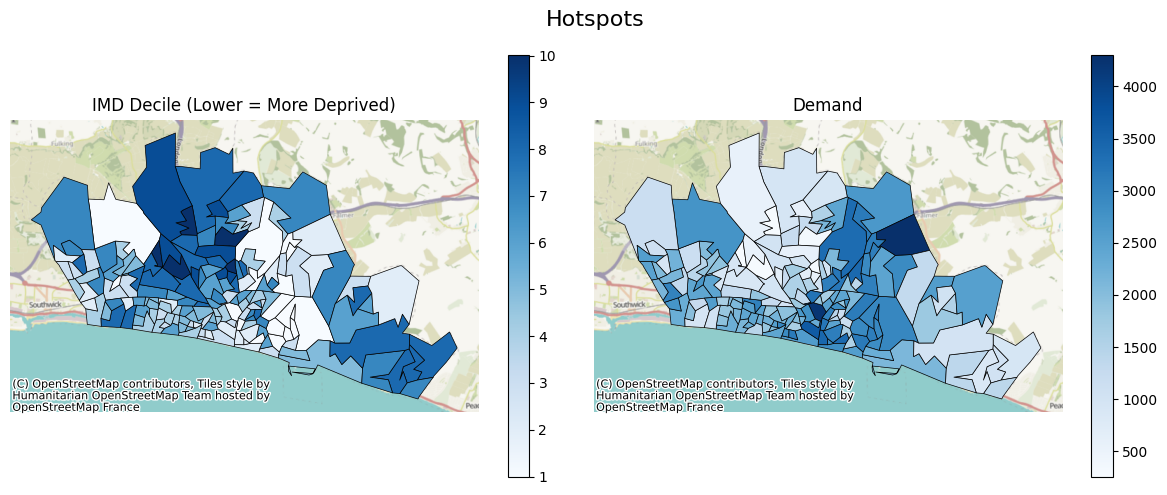

In [11]:
# First we create blank subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Now we pass the relevant axis into our plot_hotspots function
problem.plot_region_geometry_layer(plot_equity=True, ax=axes[0], plot_region_of_interest_only=True)
problem.plot_region_geometry_layer(plot_demand=True, ax=axes[1])

# Set the title for each
axes[0].set_title("IMD Decile (Lower = More Deprived)")
axes[1].set_title("Demand")

# Set an overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

And let's just compare the hotpot plots to the raw plots too. 

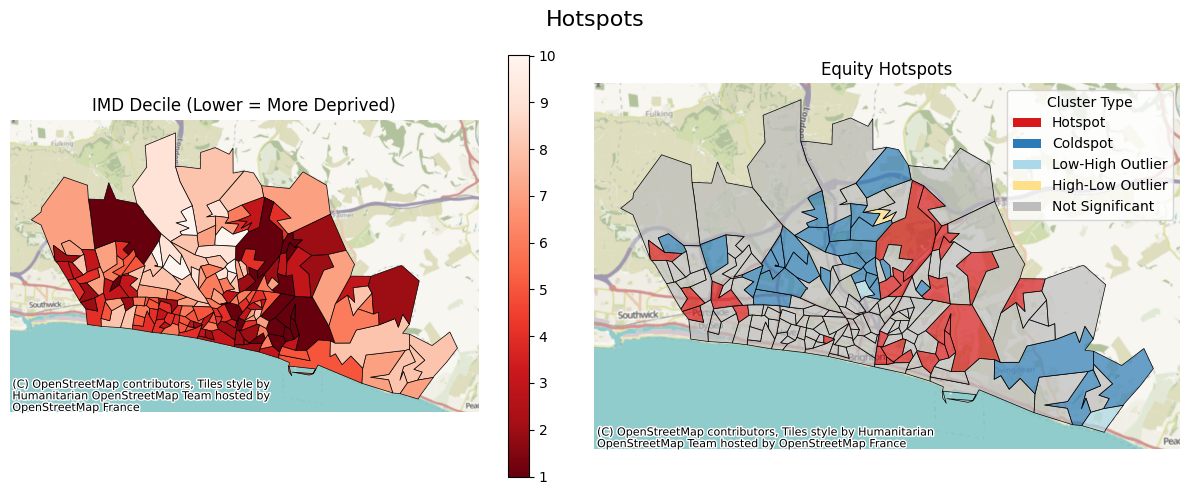

In [12]:
# First we create blank subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Now we pass the relevant axis into our plot_hotspots function
problem.plot_region_geometry_layer(plot_equity=True, ax=axes[0], plot_region_of_interest_only=True, cmap="Reds_r")
problem.plot_hotspots(hotspots_df=hotspots_equity_df, interactive=False, ax=axes[1])

# Set the title for each
axes[0].set_title("IMD Decile (Lower = More Deprived)")
axes[1].set_title("Equity Hotspots")

# Set an overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

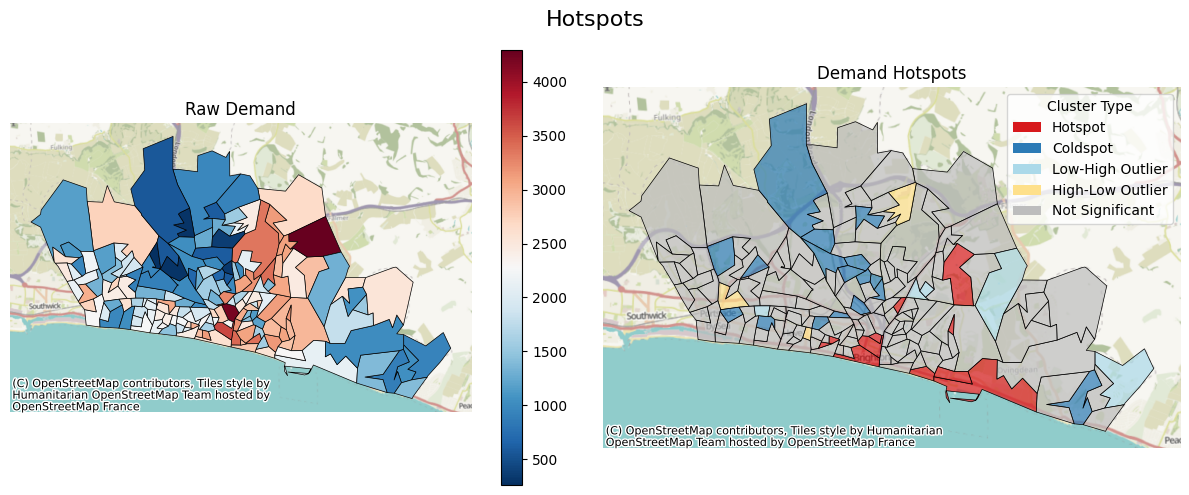

In [13]:
# First we create blank subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Now we pass the relevant axis into our plot_hotspots function
problem.plot_region_geometry_layer(plot_demand=True, ax=axes[0], cmap="RdBu_r")
problem.plot_hotspots(hotspots_df=hotspots_df, interactive=False, ax=axes[1])


# Set the title for each
axes[0].set_title("Raw Demand")
axes[1].set_title("Demand Hotspots")

# Set an overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

## Considering Demand and Deprivation Together

We can run this work with a 'what' of 'demand_equity_combined'. 

In [14]:
hotspots_combined_df = problem.get_hotspots(what="demand_equity")
hotspots_combined_df

C:\lokigi\lokigi\mixins\site_eda.py:354: UserWarning: Using cached spatial weights.
  w = self._get_weights(


,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,...,demand,IMD15,combined_score,demand_level,equity_level,attribute_typology,local_moran_i,p_value,quadrant,cluster_type
0,16356,E01016849,Brighton and Hove 026A,Brighton and Hove 026A,529362,104513,-0.16464,50.82570,2e95f9d0-9795-4cd4-83d1-3a40898b6c89,"POLYGON ((529551.999 104581, 529547.002 104555...",...,1843,5,0.217900,Medium,Medium,Medium Demand / Medium Deprivation,0.045441,0.426,3,Not Significant
1,16357,E01016850,Brighton and Hove 029A,Brighton and Hove 029A,529926,104360,-0.15669,50.82420,74a1b81a-ffc0-4c96-82ef-c63e7ec28eaf,"POLYGON ((530066.027 104493.355, 529958.177 10...",...,2433,4,0.358936,Medium,Medium,Medium Demand / Medium Deprivation,0.076936,0.210,1,Not Significant
2,16358,E01016851,Brighton and Hove 029B,Brighton and Hove 029B,529674,104404,-0.16025,50.82465,a24f39b6-85f2-4ac6-8af8-f8d205b14b58,"POLYGON ((529453.266 104354.713, 529547.002 10...",...,2041,5,0.245155,Medium,Medium,Medium Demand / Medium Deprivation,-0.170309,0.037,2,Low-High Outlier
3,16359,E01016852,Brighton and Hove 026B,Brighton and Hove 026B,529680,104641,-0.16008,50.82678,9d674ffc-b718-4555-b669-0a5e6dc98129,"POLYGON ((529787.909 104744.63, 529784.999 104...",...,2540,3,0.439379,High,High,High Demand / High Deprivation,0.469248,0.086,1,Not Significant
4,16360,E01016853,Brighton and Hove 026C,Brighton and Hove 026C,529443,104770,-0.16340,50.82799,7087f545-a012-4c31-afdb-73df930edc2b,"POLYGON ((529461.706 104928.879, 529663.936 10...",...,2233,5,0.271584,Medium,Medium,Medium Demand / Medium Deprivation,0.071052,0.066,3,Not Significant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,16516,E01017010,Brighton and Hove 017D,Brighton and Hove 017D,536120,105803,-0.06826,50.83575,e99d0ceb-67dc-4d7b-ab1f-ab8b58230e95,"POLYGON ((536567.096 105821.386, 536031.682 10...",...,1064,8,0.044268,Low,Low,Low Demand / Low Deprivation,0.472135,0.230,3,Not Significant
161,16517,E01017011,Brighton and Hove 017E,Brighton and Hove 017E,537345,105806,-0.05088,50.83549,d60da5d5-da96-4bed-a4e1-f93ffc876538,"POLYGON ((537990.001 104635.399, 537733.25 105...",...,2536,2,0.501266,High,High,High Demand / High Deprivation,-0.365030,0.103,4,Not Significant
162,16518,E01017012,Brighton and Hove 017F,Brighton and Hove 017F,535917,104786,-0.07152,50.82666,91575aee-ce23-436e-b85d-d0a94dbcef74,"POLYGON ((536031.682 105223.601, 536625.001 10...",...,1800,6,0.169585,Medium,Low,Medium Demand / Low Deprivation,0.035606,0.440,3,Not Significant
163,32444,E01033328,Brighton and Hove 027F,Brighton and Hove 027F,531208,104687,-0.13838,50.82685,f80f534f-bb85-49f8-9b67-730ecab28bad,"POLYGON ((531414.796 104753.739, 531358 104504...",...,2323,3,0.397561,Medium,High,Medium Demand / High Deprivation,0.280910,0.035,1,Hotspot


<Axes: title={'center': 'Combined Demand / Deprivation Hotspots (multiply)'}>

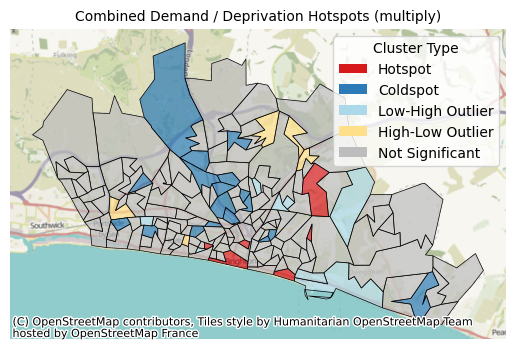

In [15]:
problem.plot_hotspots(hotspots_df=hotspots_combined_df, interactive=False)


We can also explore the same plot interactively. 

In [16]:
problem.plot_hotspots(hotspots_df=hotspots_combined_df, interactive=True)

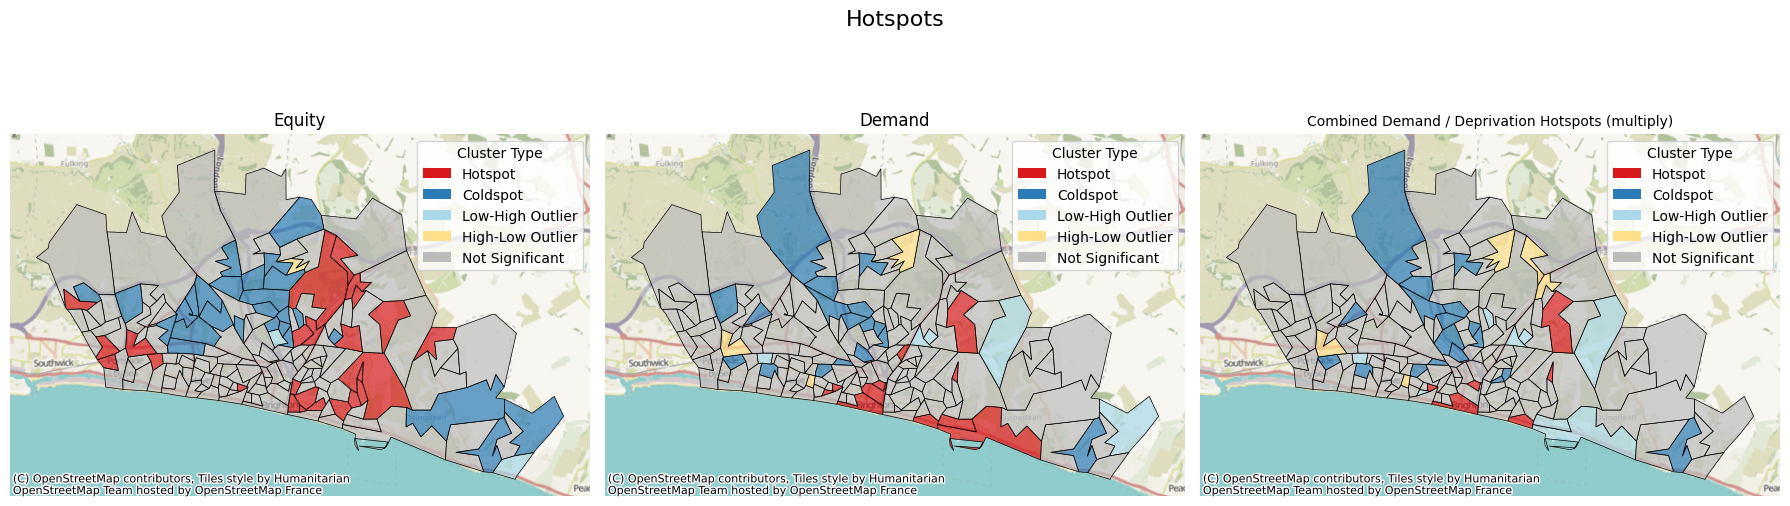

In [17]:
# First we create blank subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Now we pass the relevant axis into our plot_hotspots function
problem.plot_hotspots(hotspots_df=hotspots_equity_df, interactive=False, ax=axes[0])
problem.plot_hotspots(hotspots_df=hotspots_df, interactive=False, ax=axes[1])
problem.plot_hotspots(hotspots_df=hotspots_combined_df, interactive=False, ax=axes[2])

# Set the title for each
axes[0].set_title("Equity")
axes[1].set_title("Demand")

# Set an overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

We can also run another type of plot that is specifically interested in the quadrants. 

C:\lokigi\lokigi\mixins\site_eda.py:354: UserWarning: Using cached spatial weights.
  w = self._get_weights(


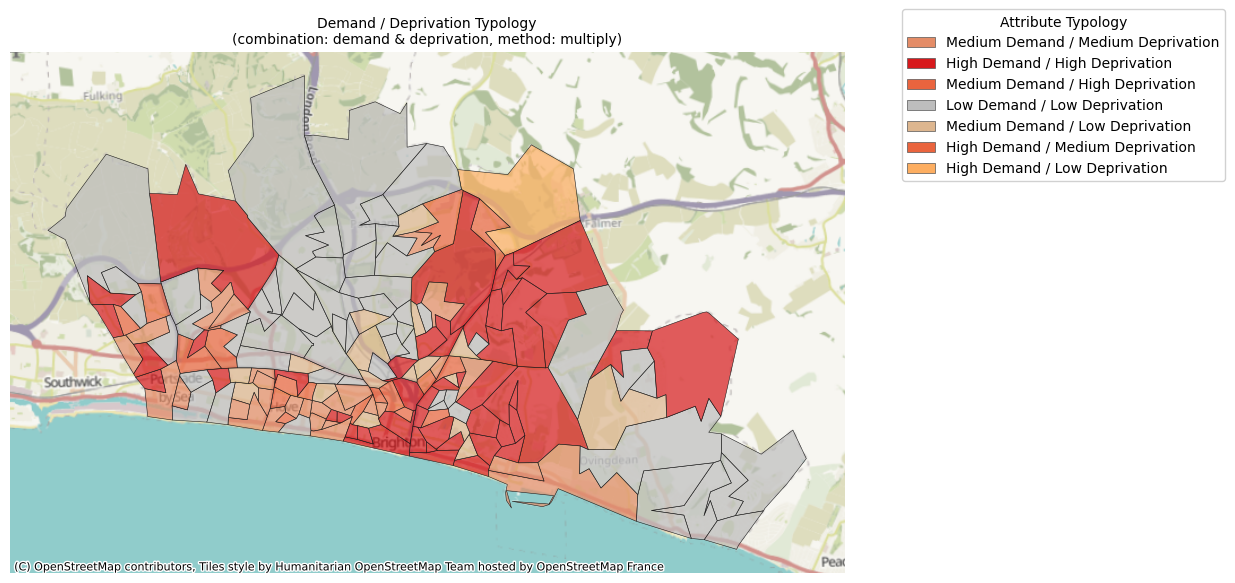

In [18]:
problem.plot_quadrant_map(figsize=(12, 7));

C:\lokigi\lokigi\mixins\site_eda.py:354: UserWarning: Using cached spatial weights.
  w = self._get_weights(


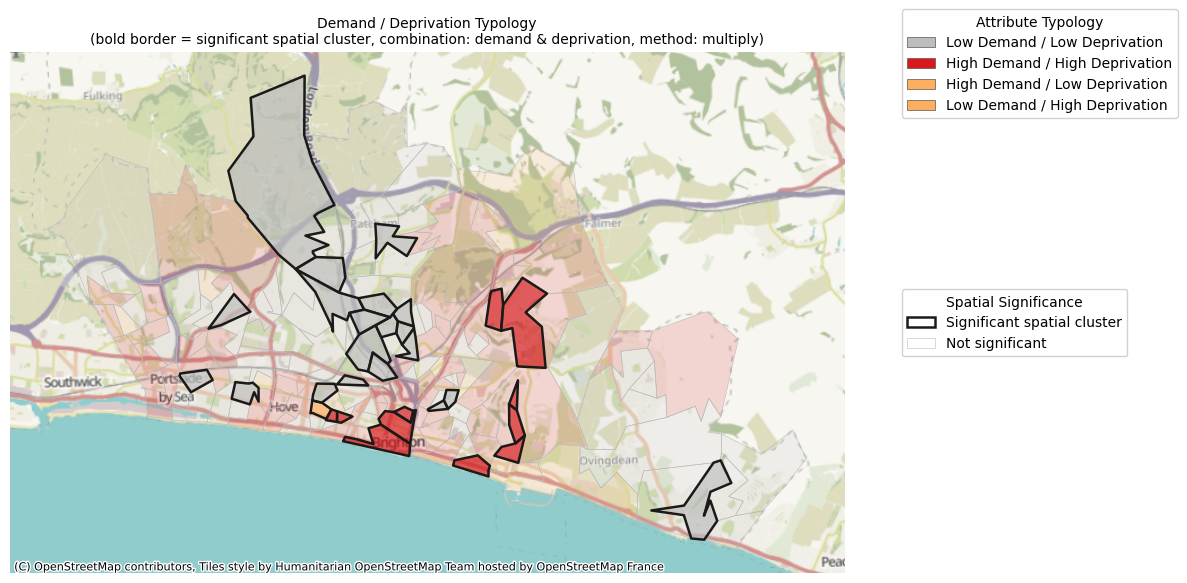

In [19]:
problem.plot_quadrant_map(significance_threshold=0.1, figsize=(12, 7), n_bins=2);

C:\lokigi\lokigi\mixins\site_eda.py:354: UserWarning: Using cached spatial weights.
  w = self._get_weights(


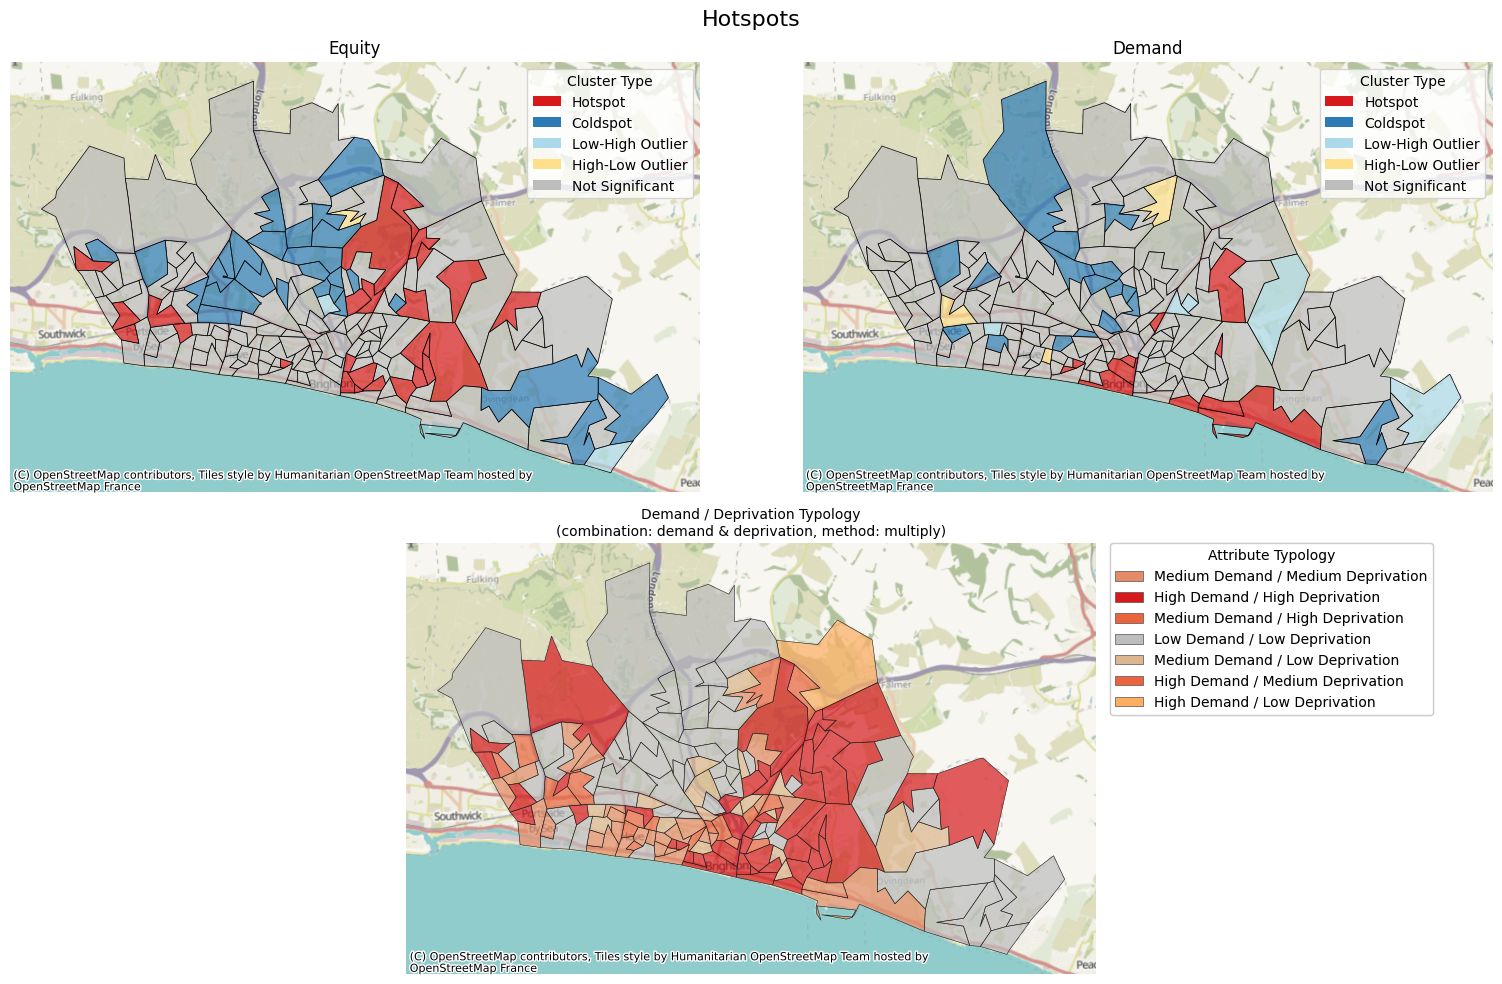

In [20]:
# Create a 2x2 grid
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row spanning both columns
ax3 = fig.add_subplot(gs[1, :])

# Plot
problem.plot_hotspots(
    hotspots_df=hotspots_equity_df,
    interactive=False,
    ax=ax1,
)

problem.plot_hotspots(
    hotspots_df=hotspots_df,
    interactive=False,
    ax=ax2,
)

problem.plot_quadrant_map(ax=ax3)

# Titles
ax1.set_title("Equity")
ax2.set_title("Demand")

# Overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

C:\lokigi\lokigi\mixins\site_eda.py:354: UserWarning: Using cached spatial weights.
  w = self._get_weights(


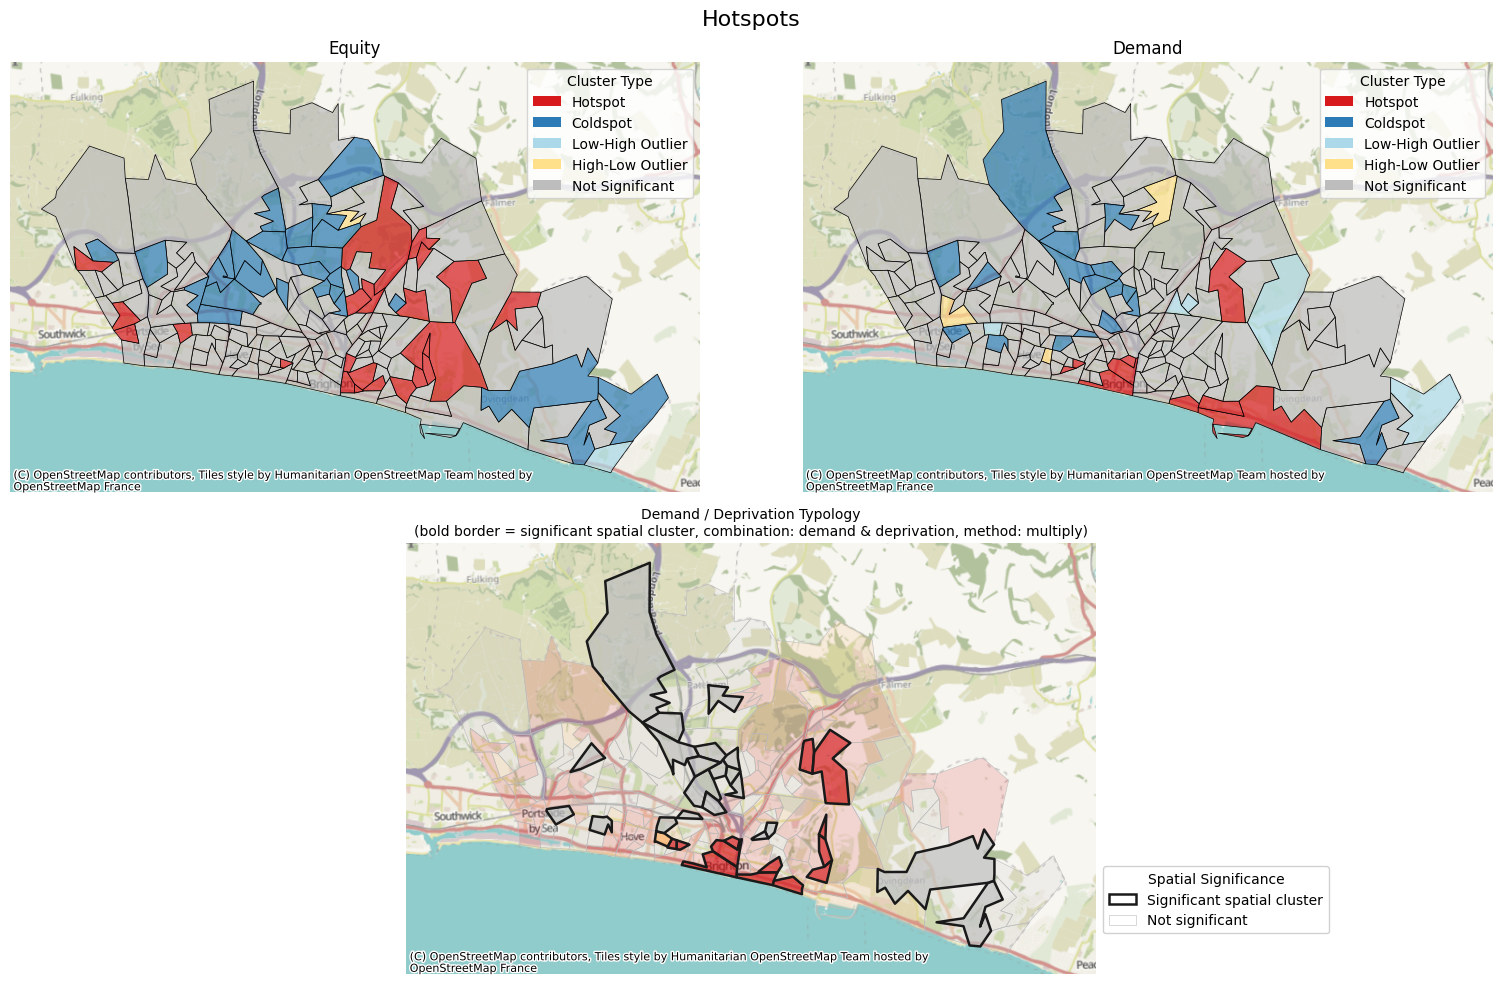

In [21]:
# Create a 2x2 grid
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row spanning both columns
ax3 = fig.add_subplot(gs[1, :])

# Plot
problem.plot_hotspots(
    hotspots_df=hotspots_equity_df,
    interactive=False,
    ax=ax1,
)

problem.plot_hotspots(
    hotspots_df=hotspots_df,
    interactive=False,
    ax=ax2,
)

problem.plot_quadrant_map(n_bins=2, significance_threshold=0.1, ax=ax3)

# Titles
ax1.set_title("Equity")
ax2.set_title("Demand")

# Overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

### Evaluating hotspots with our solution

Once we solve, we can identify another type of hotspot:

- High deprivation and high travel times (and other associated quadrants like low deprivation and low travel times)
- High demand and high travel times (and other associated quadrants like low demand and low travel times)

In [ ]:
solution = problem.solve(p=3)

In [ ]:
solution.plot_n_best_combinations(3);

As a reminder, we can access the solutions like this:

In [ ]:
solution.show_solutions(n_best=3)

And we can then access individual detailed solution dataframes with per-region travel times like this: 

In [ ]:
solution.show_solutions(n_best=1)["problem_df"].iloc[0]

As before, we can still plot our standard hotspot maps. 

In [ ]:
# Create a 2x2 grid
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row spanning both columns
ax3 = fig.add_subplot(gs[1, :])

# Plot
solution.plot_hotspots(
    interactive=False,
    what="equity",
    ax=ax1,
)

solution.plot_hotspots(
    what="demand",
    interactive=False,
    ax=ax2,
)

solution.plot_quadrant_map(ax=ax3)

# Titles
ax1.set_title("Equity")
ax2.set_title("Demand")

# Overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

But we also have two more options available to us:

- travel_equity
- travel_demand

In [ ]:
# Create a 2x2 grid
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row spanning both columns
ax3 = fig.add_subplot(gs[1, :])

solution.plot_best_combination(ax=ax1, cmap="RdBu_r")
problem.plot_region_geometry_layer(plot_equity=True, ax=ax2, plot_region_of_interest_only=True, cmap="Reds_r")

solution.plot_quadrant_map(what="travel_equity", ax=ax3)


# Titles
ax1.set_title("Travel Times")
ax2.set_title("Equity")

# Overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()


In [ ]:
# Create a 2x2 grid
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row spanning both columns
ax3 = fig.add_subplot(gs[1, :])

solution.plot_best_combination(ax=ax1, cmap="RdBu_r")
problem.plot_region_geometry_layer(plot_demand=True, ax=ax2, plot_region_of_interest_only=True, cmap="Reds")
solution.plot_quadrant_map(what="travel_demand", ax=ax3)

# Titles
ax1.set_title("Travel Times")
ax2.set_title("Demand")

# Overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()


## Repeating for a larger region

Note that in this dataset, we don't have any demand. 

Therefore, demand is set to be equal across all regions. 

In [ ]:
problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/devon_mius.geojson",
    candidate_id_col="Facility_Name"
    )

problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3c_interactive_plots_travel/raw/main/h6_3c_interactive_plots_travel/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix_public_transport_extended.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_equity_data(
    "../../../sample_data/Index_of_Multiple_Deprivation_(Dec_2015)_Lookup_in_England.csv",
    equity_col="IMD15",
    common_col="LSOA11NM",
    label="Indices of Multiple Deprivation",
    continuous_measure=True,
    reverse=False
    )

In [ ]:
# First we create blank subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Now we pass the relevant axis into our plot_hotspots function
problem.plot_region_geometry_layer(plot_equity=True, ax=axes[0], plot_region_of_interest_only=True, cmap="Reds_r")
problem.plot_hotspots(interactive=False, what="equity", ax=axes[1], significance_threshold=0.1)

# Set the title for each
axes[0].set_title("IMD Decile (Lower = More Deprived)")
axes[1].set_title("IMD Decile (Hotspots = Deprived, Coldspots = Less Deprived)")

# Set an overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()

Given the larger number of small LSOAs in the more densely populated areas, this is where the interactive maps can prove more useful. 

In [ ]:
problem.plot_hotspots(interactive=True, what="equity", ax=axes[1], significance_threshold=0.1)

We'll solve for a number of sites.

In [ ]:
solution = problem.solve(p=3)

And we will look for hospots of high deprivation and high travel times. 

In [ ]:
# Create a 2x2 grid
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row spanning both columns
ax3 = fig.add_subplot(gs[1, :])

solution.plot_best_combination(ax=ax1, cmap="RdBu_r")
problem.plot_region_geometry_layer(plot_equity=True, ax=ax2, plot_region_of_interest_only=True, cmap="Reds_r")

solution.plot_quadrant_map(what="travel_equity", ax=ax3)

# Titles
ax1.set_title("Travel Times")
ax2.set_title("Equity")

# Overall title
fig.suptitle("Hotspots", fontsize=16)

plt.tight_layout()
plt.show()


We can also compare the effect of a 2x2 vs 3x3 plot. 

In [ ]:
# Create a 2x2 grid
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(1, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

solution.plot_quadrant_map(what="travel_equity", ax=ax1, n_bins=2, significance_threshold=0.05)
solution.plot_quadrant_map(what="travel_equity", ax=ax2, n_bins=3)

ax1.set_title("Four bins with strict significance threshold: above median travel time = poor access")
ax2.set_title("Nine bins with strict significance threshold: above upper third of travel time = poor access")


plt.tight_layout()
plt.show()


And once again, we can opt for an interactive map. 

In [ ]:
solution.plot_quadrant_map(what="travel_equity", interactive=True)

We can also explore the underlying data. 

In [ ]:
df = solution.get_hotspots(what="travel_equity")
df

In [ ]:
df.groupby("attribute_typology")[["IMD15", "min_cost"]].mean().round(1)